In [23]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
grassknoted_asl_alphabet_path = kagglehub.dataset_download('grassknoted/asl-alphabet')

print('Data source import complete.')


Data source import complete.


In [24]:
print("the path of dataset:")
print(grassknoted_asl_alphabet_path)

the path of dataset:
/kaggle/input/asl-alphabet


In [25]:
import os

print(os.listdir(grassknoted_asl_alphabet_path))

['asl_alphabet_test', 'asl_alphabet_train']


In [26]:
TRAIN_DIR = grassknoted_asl_alphabet_path + "/asl_alphabet_train/asl_alphabet_train"
TEST_DIR = grassknoted_asl_alphabet_path + "/asl_alphabet_test/asl_alphabet_test"

print("Training folder exists:", os.path.exists(TRAIN_DIR))
print("Test folder exists:", os.path.exists(TEST_DIR))

Training folder exists: True
Test folder exists: True


In [27]:

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

In [28]:

print(f"Training folder exists: {os.path.exists(TRAIN_DIR)}")
print(f"Test folder exists: {os.path.exists(TEST_DIR)}")


Training folder exists: True
Test folder exists: True


In [29]:

classes = sorted(os.listdir(TRAIN_DIR))
print(f"\n CLASS INFORMATION:")
print(f"Number of classes: {len(classes)}")
print("All classes:", classes)



 CLASS INFORMATION:
Number of classes: 29
All classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [30]:
class_counts = {}
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        num_images = len(image_files)
        class_counts[cls] = num_images
        print(f"  {cls}: {num_images} images")

  A: 3000 images
  B: 3000 images
  C: 3000 images
  D: 3000 images
  E: 3000 images
  F: 3000 images
  G: 3000 images
  H: 3000 images
  I: 3000 images
  J: 3000 images
  K: 3000 images
  L: 3000 images
  M: 3000 images
  N: 3000 images
  O: 3000 images
  P: 3000 images
  Q: 3000 images
  R: 3000 images
  S: 3000 images
  T: 3000 images
  U: 3000 images
  V: 3000 images
  W: 3000 images
  X: 3000 images
  Y: 3000 images
  Z: 3000 images
  del: 3000 images
  nothing: 3000 images
  space: 3000 images


In [31]:
total_images = sum(class_counts.values())
print(f"Total training images: {total_images:,}")
print(f"Average per class: {total_images/len(classes):.0f} images")


Total training images: 87,000
Average per class: 3000 images


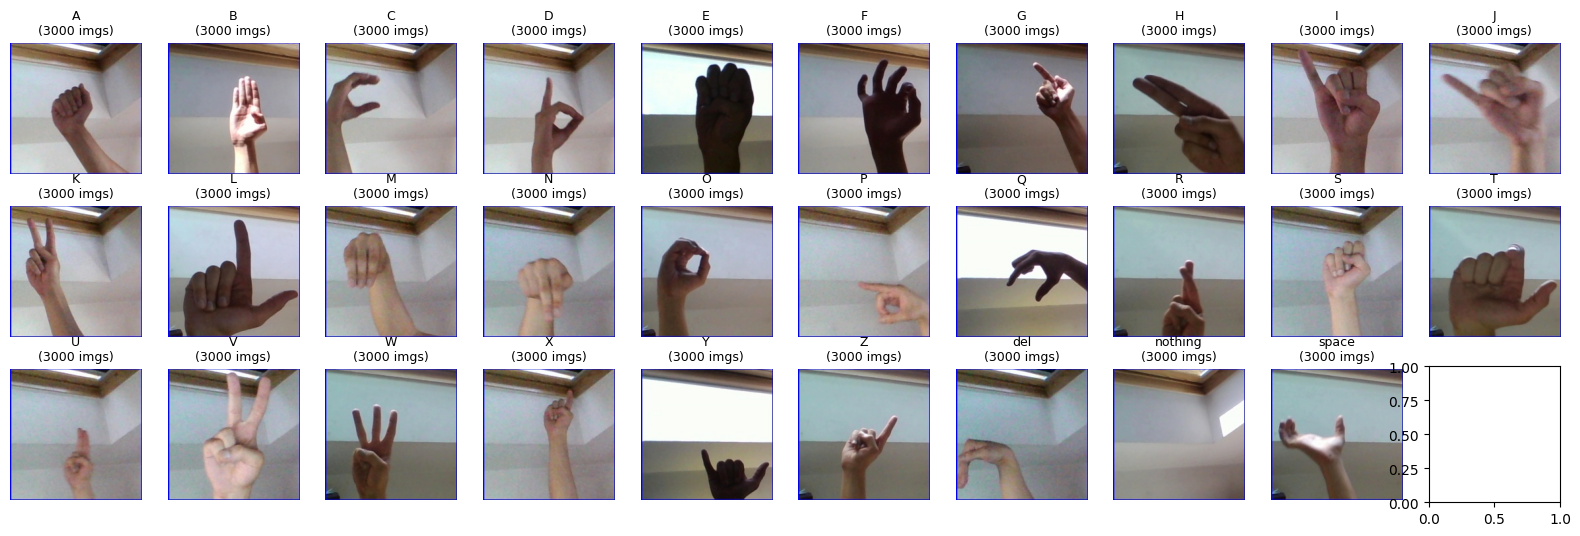

In [32]:
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i, cls in enumerate(classes[:30]):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if image_files:
            img_path = os.path.join(cls_path, image_files[0])
            img = mpimg.imread(img_path)

            row = i // 10
            col = i % 10
            axes[row, col].imshow(img)
            axes[row, col].set_title(f"{cls}\n({class_counts[cls]} imgs)", fontsize=9)
            axes[row, col].axis('off')

In [33]:

sample_class = classes[0]
sample_path = os.path.join(TRAIN_DIR, sample_class)
sample_image = [f for f in os.listdir(sample_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][0]
img = mpimg.imread(os.path.join(sample_path, sample_image))

print(f"Image shape: {img.shape} (Height, Width, Channels)")
print(f"Image dtype: {img.dtype}")
print(f"Pixel value range: {img.min()} to {img.max()}")


Image shape: (200, 200, 3) (Height, Width, Channels)
Image dtype: uint8
Pixel value range: 0 to 255


In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
SEED = 42
VALIDATION_SPLIT = 0.2  # 20% for validation


In [35]:
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0, 1]
    validation_split=VALIDATION_SPLIT,

    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest',

    horizontal_flip=False,

)


In [36]:

train_generator = train_datagen.flow_from_directory(
TRAIN_DIR,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='training',
seed=SEED,
shuffle=True
)


Found 69600 images belonging to 29 classes.


In [37]:

validation_generator = train_datagen.flow_from_directory(
TRAIN_DIR,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='validation',
seed=SEED,
shuffle=False
)


Found 17400 images belonging to 29 classes.


In [38]:

print(f"Training samples: {train_generator.samples:,}")
print(f"Validation samples: {validation_generator.samples:,}")
print(f"Total samples: {train_generator.samples + validation_generator.samples:,}")
print(f"Number of classes: {len(train_generator.class_indices)}")
print(f"Classes: {list(train_generator.class_indices.keys())}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}")
print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(validation_generator)}")


Training samples: 69,600
Validation samples: 17,400
Total samples: 87,000
Number of classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Batch size: 64
Image size: (224, 224)
Training batches: 1088
Validation batches: 272


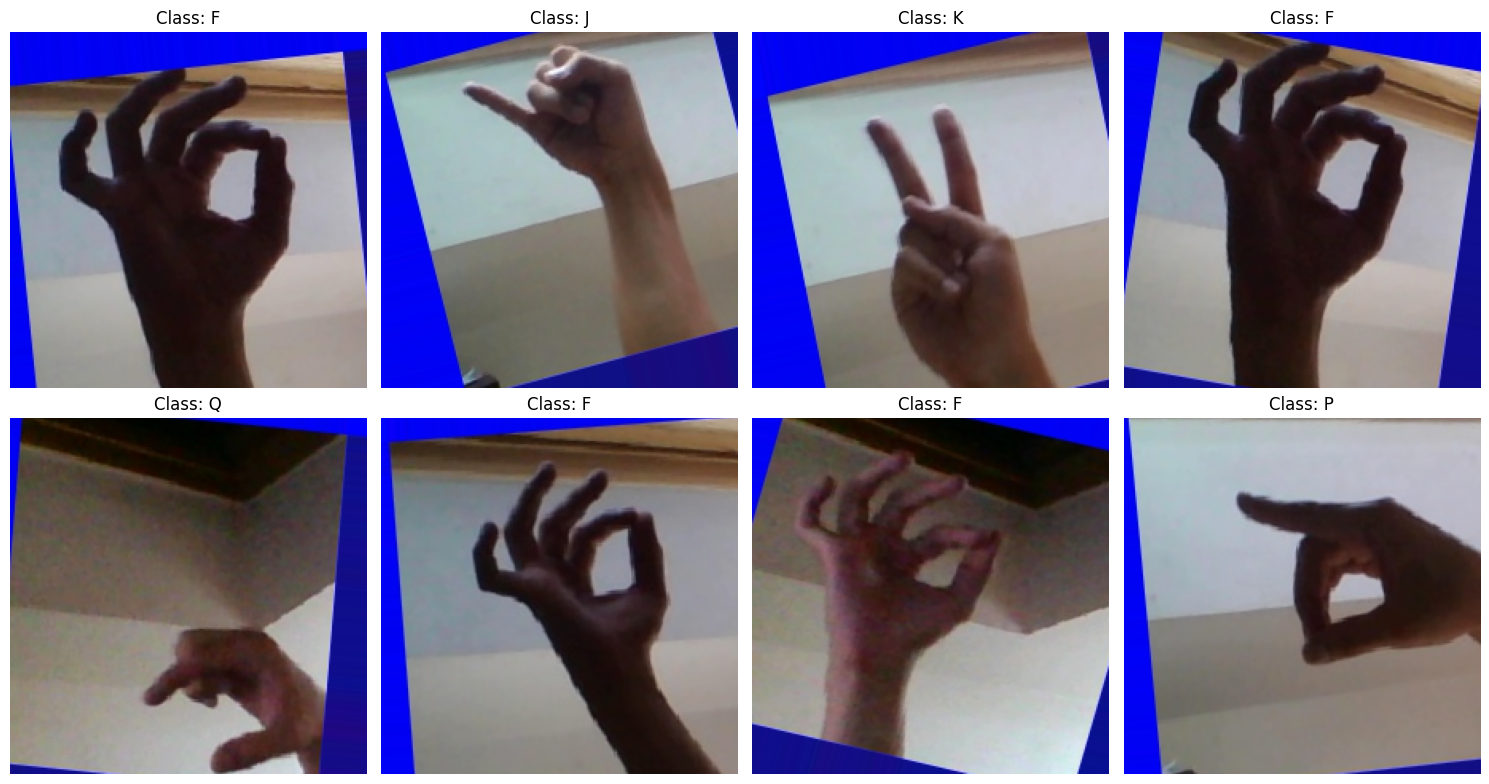

In [39]:
images, labels = next(train_generator)

plt.figure(figsize=(15, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])

    class_idx = labels[i].argmax()
    class_name = list(train_generator.class_indices.keys())[class_idx]

    plt.title(f"Class: {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [40]:

print(f"Pixel range before: 0-255")
print(f"Pixel range after: {images.min():.3f} to {images.max():.3f}")
print(f"Image shape in batch: {images[0].shape}")


Pixel range before: 0-255
Pixel range after: 0.000 to 1.000
Image shape in batch: (224, 224, 3)


In [41]:
test_base = "/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1"

if os.path.exists(TEST_DIR):
    print(f"Test directory exists: {TEST_DIR}")

    # List what's inside
    print(f"Contents of test directory:")
    for item in os.listdir(TEST_DIR):
        item_path = os.path.join(TEST_DIR, item)
        if os.path.isdir(item_path):
            print(f"{item}/ (directory)")
        else:
            print(f"{item} (file)")


Test directory exists: /kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test
Contents of test directory:
A_test.jpg (file)
E_test.jpg (file)
L_test.jpg (file)
N_test.jpg (file)
S_test.jpg (file)
D_test.jpg (file)
G_test.jpg (file)
I_test.jpg (file)
W_test.jpg (file)
M_test.jpg (file)
nothing_test.jpg (file)
X_test.jpg (file)
H_test.jpg (file)
Q_test.jpg (file)
C_test.jpg (file)
T_test.jpg (file)
P_test.jpg (file)
V_test.jpg (file)
Y_test.jpg (file)
U_test.jpg (file)
space_test.jpg (file)
O_test.jpg (file)
B_test.jpg (file)
R_test.jpg (file)
F_test.jpg (file)
Z_test.jpg (file)
J_test.jpg (file)
K_test.jpg (file)


In [42]:
test_base_path = "/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1"
if os.path.exists(test_base_path):
    for root, dirs, files in os.walk(test_base_path):
        level = root.replace(test_base_path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)

        for file in files[:5]:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

    test_count = 0
    for root, dirs, files in os.walk(test_base_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                test_count += 1




Import for model

In [43]:
# Imports لـ ConvNeXtTiny و GUI
import tensorflow as tf
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


ConvNeXtTiny Model

In [45]:
# ConvNeXtTiny - Trained by Shahd (4th Model - Highest Accuracy Expected)

# Load base model
weights_path = '/kaggle/input/waightsconnexttiny/convnext_tiny_notop.h5'
base_model = ConvNeXtTiny(weights=weights_path, include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(len(classes), activation='softmax')  # number of classes = 29
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │        14,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,228,733 (107.68 MB)

 Trainable params: 408,605 (1.56 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

Head + Fine-tuning

In [48]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

# Train head only (10 epochs)
print("Training head only...")
history_head = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stopping, reduce_lr]
)

# Fine-tuning last 40 layers
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# Save model
#model.save("convnext_tiny_asl.h5")
#print("ConvNeXtTiny  saved - Expected 99.8%+ accuracy!")

Training head only...
Epoch 1/5
 435/1088 ━━━━━━━━━━━━━━━━━━━━ 9:16 853ms/step - accuracy: 0.3818 - loss: 2.1454

E0000 00:00:1766364858.299448     245 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766364858.432021     245 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1155s 1s/step - accuracy: 0.3925 - loss: 2.1084 - val_accuracy: 0.1678 - val_loss: 2.8767 - learning_rate: 1.0000e-05
Epoch 2/5
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1127s 1s/step - accuracy: 0.4548 - loss: 1.8821 - val_accuracy: 0.2048 - val_loss: 2.7088 - learning_rate: 1.0000e-05
Epoch 3/5
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1128s 1s/step - accuracy: 0.5085 - loss: 1.6817 - val_accuracy: 0.2231 - val_loss: 2.6449 - learning_rate: 1.0000e-05
Epoch 4/5
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1140s 1s/step - accuracy: 0.5484 - loss: 1.5351 - val_accuracy: 0.2649 - val_loss: 2.4780 - learning_rate: 1.0000e-05
Epoch 5/5
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1167s 1s/step - accuracy: 0.5879 - loss: 1.4083 - val_accuracy: 0.2822 - val_loss: 2.4236 - learning_rate: 1.0000e-05


In [49]:
print("Fine-tuning ConvNeXtTiny...")
history_fine = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stopping, reduce_lr]
)


Fine-tuning ConvNeXtTiny...
Epoch 1/5
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1181s 1s/step - accuracy: 0.6103 - loss: 1.3213 - val_accuracy: 0.2996 - val_loss: 2.3292 - learning_rate: 1.0000e-05
Epoch 2/5
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1160s 1s/step - accuracy: 0.6308 - loss: 1.2490 - val_accuracy: 0.3182 - val_loss: 2.2841 - learning_rate: 1.0000e-05
Epoch 3/5
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1178s 1s/step - accuracy: 0.6502 - loss: 1.1817 - val_accuracy: 0.3351 - val_loss: 2.2327 - learning_rate: 1.0000e-05
Epoch 4/5
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1170s 1s/step - accuracy: 0.6654 - loss: 1.1187 - val_accuracy: 0.3314 - val_loss: 2.2459 - learning_rate: 1.0000e-05
Epoch 5/5
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1125s 1s/step - accuracy: 0.6833 - loss: 1.0645 - val_accuracy: 0.3583 - val_loss: 2.1448 - learning_rate: 1.0000e-05


In [50]:
model.save("convnext_tiny_asl.h5")
print("convnext_tiny_asl.h5")

convnext_tiny_asl.h5


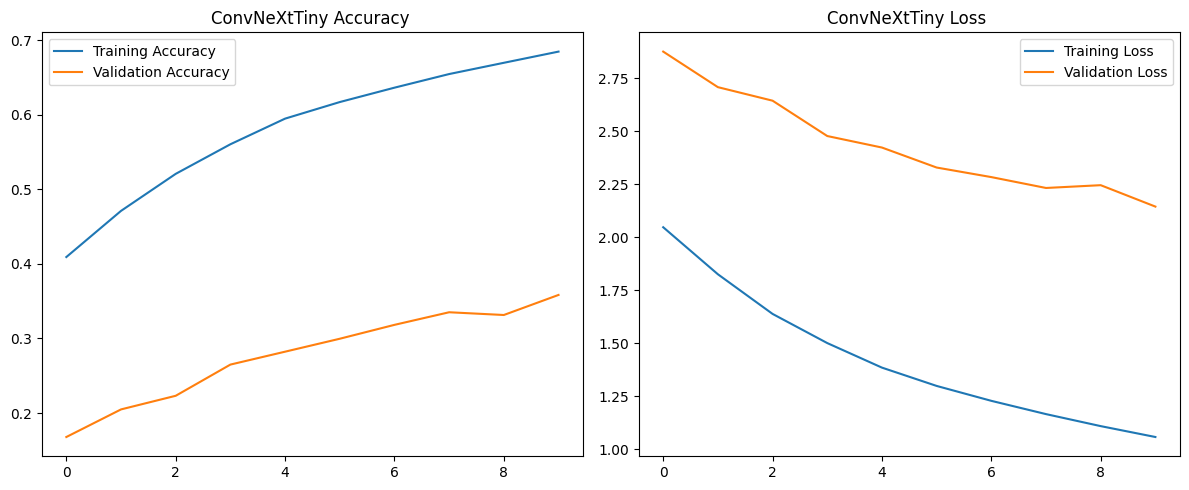

In [51]:
# حفظ الموديل النهائي باسمك
#model.save("convnext_tiny_asl.h5")
#print("convnext_tiny_asl.h5")

# رسم الـ accuracy والـ loss (للتقرير والعرض)
acc = history_head.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_head.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_head.history['loss'] + history_fine.history['loss']
val_loss = history_head.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('ConvNeXtTiny Accuracy ')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('ConvNeXtTiny Loss ')
plt.legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=300)
plt.show()

272/272 ━━━━━━━━━━━━━━━━━━━━ 197s 710ms/step
Final Validation Accuracy: 36.01724137931034
              precision    recall  f1-score   support

           A       0.60      0.43      0.50       600
           B       0.35      0.86      0.50       600
           C       0.80      0.76      0.78       600
           D       0.96      0.69      0.81       600
           E       0.56      0.45      0.50       600
           F       0.74      0.93      0.82       600
           G       0.47      0.67      0.56       600
           H       0.39      0.48      0.43       600
           I       0.45      0.19      0.27       600
           J       0.49      0.39      0.43       600
           K       0.53      0.80      0.64       600
           L       0.80      0.57      0.66       600
           M       0.61      0.09      0.15       600
           N       0.12      0.39      0.18       600
           O       0.69      0.11      0.19       600
           P       0.33      0.13      0.19  

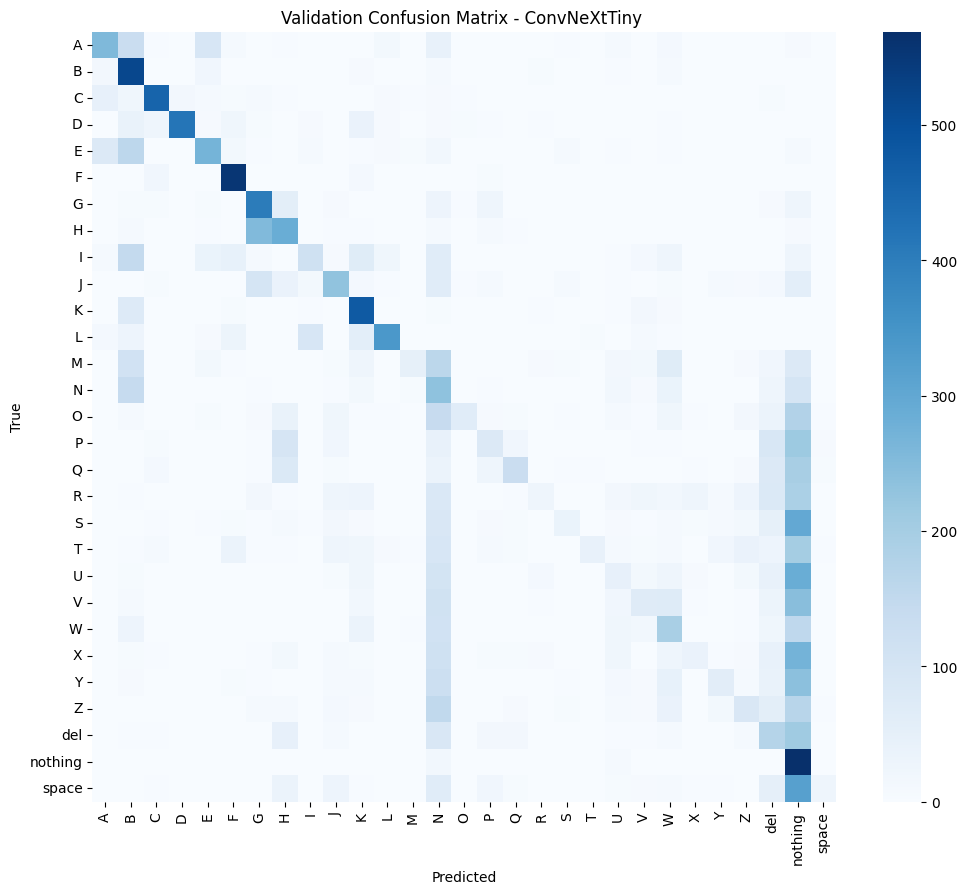

In [52]:
# Evaluation على validation (الداتا الكبيرة)
val_preds = model.predict(validation_generator)
val_labels = validation_generator.classes

y_pred = np.argmax(val_preds, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Final Validation Accuracy:", np.mean(y_pred == val_labels) * 100)

print(classification_report(val_labels, y_pred, target_names=classes))

cm = confusion_matrix(val_labels, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Validation Confusion Matrix - ConvNeXtTiny ")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("validation_confusion_matrix.png", dpi=300)
plt.show()